# Session 5 - Time-series Forecasting and Multi-horizon Evaluation

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at Abali  
**Session length:** 90 minutes  
**Data source (the only one used):** `data/raw/abali.xlsx`

---

## Learning objectives

By the end of this session you will be able to:

1. Explain the difference between a **forecast origin**, a **lead time** and a **forecast horizon**, and why a 24-hour forecast is not a scaled 3-hour forecast.
2. Implement **direct multi-horizon** forecasting (one model per horizon) and **recursive multi-step** forecasting (one model fed its own predictions), and know when each is appropriate.
3. Measure **error growth with lead time** and interpret it physically.
4. Run **walk-forward validation** - retraining as the record advances - and report the dispersion across folds.
5. Build a **skill-versus-horizon curve** against two baselines (persistence and diurnal climatology).
6. Name and avoid the mistakes that specifically break machine-learning weather forecasts.

## Prerequisites

Sessions 1-4. The helpers are repeated below, unchanged and self-contained.

---

## 1. Setup

Everything is rebuilt from `data/raw/abali.xlsx` in memory. LightGBM or XGBoost is used when available; otherwise the notebook falls back to scikit-learn's `GradientBoostingRegressor` so that the session always runs.

In [1]:
# ---------------------------------------------------------------------------
# Session 5 setup (self-contained)
# ---------------------------------------------------------------------------
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

QUICK_MODE = True
N_TREES = 80 if QUICK_MODE else 300
N_JOBS = 2               # one worker process per job: keep this small on a laptop
HORIZONS = [3, 6, 12, 24]

HAS_XGB = False
try:
    import xgboost
    HAS_XGB = True
    XGB_VERSION = xgboost.__version__
except Exception as exc:
    XGB_VERSION = 'not installed'
    print('[optional] xgboost not available:', exc)

HAS_LGBM = False
try:
    import lightgbm
    HAS_LGBM = True
    LGBM_VERSION = lightgbm.__version__
except Exception as exc:
    LGBM_VERSION = 'not installed'
    print('[optional] lightgbm not available:', exc)

if not (HAS_XGB or HAS_LGBM):
    print('[fallback] no boosted-tree library: using sklearn GradientBoostingRegressor')

RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError('Could not find abali.xlsx. Expected at ' + candidates[0] +
                            ' relative to the repository root.')


RAW_PATH = resolve_raw_path()
COL_MAP = {'DateTimes': 'datetime', 'Wind Speed(m/s)': 'wind_speed_ms',
           'Wind Direction(D)': 'wind_direction_deg', 'Air Pressure(hPa)': 'pressure_hpa',
           'Air Temperature(C)': 'temperature_c', 'rel. Humidity(%)': 'humidity'}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']
PHYSICAL_BOUNDS = {'wind_speed_ms': (0.0, 60.0), 'wind_direction_deg': (0.0, 360.0),
                   'pressure_hpa': (500.0, 1100.0), 'temperature_c': (-60.0, 60.0),
                   'humidity': (0.0, 100.0)}

print()
print('Python:', sys.version.split()[0], '| pandas:', pd.__version__)
print('xgboost:', XGB_VERSION, '| lightgbm:', LGBM_VERSION, '| QUICK_MODE:', QUICK_MODE)

using raw data file: ../../data/raw/abali.xlsx

Python: 3.13.7 | pandas: 2.3.2
xgboost: 3.2.0 | lightgbm: 4.7.0 | QUICK_MODE: True


In [2]:
def load_abali_hourly(path=RAW_PATH, verbose=False):
    """Raw Abali Excel -> clean hourly DataFrame, entirely in memory."""
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')
    raw = pd.read_excel(path)[list(COL_MAP)].rename(columns=COL_MAP)
    raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
    for c in DATA_COLS:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    raw[DATA_COLS] = raw[DATA_COLS].mask(raw[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        raw[c] = raw[c].mask((raw[c] < lo) | (raw[c] > hi))
    raw = raw.dropna(subset=['datetime'])
    raw = raw.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='first')
    g = raw.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    hourly['n_obs'] = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    if verbose:
        print('hourly rows:', len(hourly), '| range:', hourly.index.min(), '->', hourly.index.max())
    return hourly


def build_horizon_dataset(hourly, horizon, lags=(1, 2, 3, 6, 12, 24), windows=(3, 6, 24)):
    """Leakage-safe features at T, target at T+horizon (direct multi-horizon setup)."""
    df = hourly.copy()
    rad = np.radians(df['wind_direction_deg'])
    df['wind_dir_sin'] = np.sin(rad)
    df['wind_dir_cos'] = np.cos(rad)
    df = df.drop(columns=['wind_direction_deg', 'n_obs'])
    base = ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir_sin', 'wind_dir_cos']
    angular = ['wind_dir_sin', 'wind_dir_cos']
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    features = list(base)
    for c in base:
        for k in lags:
            df[c + '_lag' + str(k)] = df[c].shift(k)
            features.append(c + '_lag' + str(k))
    for c in base:
        past = df[c].shift(1)
        for w in windows:
            df[c + '_roll' + str(w) + '_mean'] = past.rolling(w).mean()
            features.append(c + '_roll' + str(w) + '_mean')
            if c not in angular:
                df[c + '_roll' + str(w) + '_max'] = past.rolling(w).max()
                features.append(c + '_roll' + str(w) + '_max')
                df[c + '_roll' + str(w) + '_std'] = past.rolling(w).std()
                features.append(c + '_roll' + str(w) + '_std')
    idx = df.index
    df['hour'] = idx.hour
    df['dayofyear'] = idx.dayofyear
    df['month'] = idx.month
    df['dayofweek'] = idx.dayofweek
    df['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24.0)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    features += ['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    valid = df[features].notna().all(axis=1) & df['target'].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, 'target'].copy()
    X.index.name = 'origin_time'
    return X, y


def chronological_split(n, frac=(0.70, 0.15, 0.15), gap=0):
    """Train / validation / test indices with a purge gap of `gap` rows."""
    n_train, n_val = int(frac[0] * n), int(frac[1] * n)
    return (np.arange(0, max(n_train - gap, 1)),
            np.arange(n_train + gap, max(n_train + n_val - gap, 1)),
            np.arange(n_train + n_val + gap, n))


def select_features(X_train, y_train, min_std=1e-8, max_pair_corr=0.98):
    """Training-only filtering: drop near-constant and near-duplicate columns."""
    keep = [c for c in X_train.columns if X_train[c].std() > min_std]
    corr = X_train[keep].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    target_corr = X_train[keep].apply(lambda col: abs(np.corrcoef(col.values, y_train.values)[0, 1]))
    dropped = []
    for col in upper.columns:
        for p in upper.index[upper[col] > max_pair_corr].tolist():
            weaker = col if target_corr[col] < target_corr[p] else p
            if weaker not in dropped and weaker in keep:
                dropped.append(weaker)
    return [c for c in keep if c not in dropped]


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def metrics(y_true, y_pred):
    """MAE, MSE, RMSE and R2."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': float(mean_absolute_error(y_true, y_pred)), 'MSE': float(mse),
            'RMSE': float(np.sqrt(mse)), 'R2': float(r2_score(y_true, y_pred))}


def diurnal_climatology(hourly, horizon, train_origin_times, origin_times):
    """Training-period mean wind speed for the hour of the TARGET time (T + H)."""
    window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
    by_hour = window.groupby(window.index.hour).mean().to_dict()
    target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
    return np.array([by_hour[h] for h in target_hour])


def booster_factory(n_estimators=200, learning_rate=0.05):
    """Return a boosted-tree model, whichever library is available."""
    if HAS_LGBM:
        return lightgbm.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                                     num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                     random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    if HAS_XGB:
        return xgboost.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                                    max_depth=5, subsample=0.8, colsample_bytree=0.8,
                                    random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    return GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                                     max_depth=3, random_state=SEED)


def rf_factory():
    return RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt', min_samples_leaf=2,
                                 random_state=SEED, n_jobs=N_JOBS)


hourly = load_abali_hourly(verbose=True)
DATA = {}
for H in HORIZONS:
    X, y = build_horizon_dataset(hourly, H)
    tr, va, te = chronological_split(len(y), gap=H)
    cols = select_features(X.iloc[tr], y.iloc[tr])
    DATA[H] = {'X_train': X.iloc[tr][cols], 'y_train': y.iloc[tr],
               'X_val': X.iloc[va][cols], 'y_val': y.iloc[va],
               'X_test': X.iloc[te][cols], 'y_test': y.iloc[te], 'features': cols,
               'X_full': X[cols], 'y_full': y,
               'val_index': va, 'train_index': tr, 'test_index': te}
print()
print('dataset ready for', HORIZONS, '- features per horizon:', {H: len(DATA[H]['features']) for H in HORIZONS})
print('the TEST block stays untouched in this session')

hourly rows: 10440 | range: 2024-01-01 00:00:00 -> 2025-03-10 23:00:00

dataset ready for [3, 6, 12, 24] - features per horizon: {3: 74, 6: 72, 12: 72, 24: 72}
the TEST block stays untouched in this session


---

## 2. The vocabulary of forecast evaluation

| Term | Meaning in this project |
|---|---|
| **forecast origin** (`T`) | the hour at which the forecast is issued; all features come from `<= T` |
| **lead time / horizon** (`H`) | how far ahead we predict: 3, 6, 12, 24 hours |
| **valid time** | `T + H`, the moment the forecast describes |
| **single-step** | predict exactly `T+1` |
| **multi-step / multi-horizon** | predict a sequence, or several fixed horizons |
| **direct strategy** | a separate model for each horizon |
| **recursive strategy** | one single-step model, whose predictions are fed back as inputs |
| **walk-forward validation** | re-fit as the record advances, then score the next block - how operational forecasts are really verified |

### Why error grows with lead time

The atmosphere forgets. The autocorrelation of hourly wind speed destroys most of the memory of the current value within about 12 hours, so a forecast at 24 h is dominated by the diurnal cycle and the season rather than by the current wind. Two consequences that shape this whole session:

1. **The useful predictors change with the horizon.** At 3 h, `wind_speed_ms` at `T` is the single most informative input. At 24 h, calendar and cyclical features matter as much as the current observation. A model that works well at one horizon is not guaranteed at another.
2. **The baselines change rank with the horizon.** Persistence is strong at 3 h and weak at 12 h; the diurnal climatology does the opposite. Both must be reported at every horizon.

### Direct versus recursive: how to choose

| | Direct (used here) | Recursive |
|---|---|---|
| Number of models | one per horizon | one |
| Error accumulation | none by construction | predictions feed predictions, so errors compound |
| Feature availability | all features observed at `T` | after step 1, every feature must be built from *predicted* values |
| When to use | fixed horizons (operational schedules) | long sequences, or when training data are too scarce for many models |

We quantify the difference later in this session with a controlled experiment.

---

## 3. Direct multi-horizon forecasting

One dataset and one model per horizon, evaluated on the identical validation rows. Persistence and the diurnal climatology are computed for every horizon as well, so the skill numbers are always relative to something.

In [3]:
def fit_and_eval(factory, D, target_block='validation'):
    """Fit on the training block, score on the requested block. Returns predictions + metrics."""
    X_te = D['X_val'] if target_block == 'validation' else D['X_test']
    y_te = D['y_val'] if target_block == 'validation' else D['y_test']
    model = factory()
    t0 = time.time()
    model.fit(D['X_train'], D['y_train'])
    fit_seconds = time.time() - t0
    pred = model.predict(X_te)
    result = {'pred': pred, 'metrics': metrics(y_te, pred), 'fit_seconds': fit_seconds}
    del model
    return result


DIRECT = {}
for H in HORIZONS:
    D = DATA[H]
    out = {}
    out['Persistence'] = {'pred': D['X_val']['wind_speed_ms'].values, 'fit_seconds': 0.0,
                          'metrics': metrics(D['y_val'], D['X_val']['wind_speed_ms'].values)}
    clim = diurnal_climatology(hourly, H, D['X_train'].index, D['X_val'].index)
    out['Diurnal climatology'] = {'pred': clim, 'fit_seconds': 0.0, 'metrics': metrics(D['y_val'], clim)}
    out['Direct random forest'] = fit_and_eval(rf_factory, D)
    out['Direct boosting'] = fit_and_eval(lambda: booster_factory(), D)
    DIRECT[H] = out

    print('--- H = {} h, validation block'.format(H))
    for name, r in out.items():
        m = r['metrics']
        print('  {:<24s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}'.format(name, m['MAE'], m['RMSE'], m['R2']))

C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:109: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


--- H = 3 h, validation block
  Persistence              MAE = 1.1200  RMSE = 1.6163  R2 = +0.0015
  Diurnal climatology      MAE = 1.5142  RMSE = 1.7998  R2 = -0.2381
  Direct random forest     MAE = 1.0029  RMSE = 1.3618  R2 = +0.2912
  Direct boosting          MAE = 1.3298  RMSE = 1.6118  R2 = +0.0070


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:109: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


--- H = 6 h, validation block
  Persistence              MAE = 1.4952  RMSE = 2.0453  R2 = -0.6037
  Diurnal climatology      MAE = 1.5150  RMSE = 1.8019  R2 = -0.2448
  Direct random forest     MAE = 1.3523  RMSE = 1.6813  R2 = -0.0837
  Direct boosting          MAE = 1.7483  RMSE = 2.0308  R2 = -0.5811


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:109: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


--- H = 12 h, validation block
  Persistence              MAE = 1.7469  RMSE = 2.3787  R2 = -0.9511
  Diurnal climatology      MAE = 1.5461  RMSE = 1.8656  R2 = -0.2001
  Direct random forest     MAE = 1.3115  RMSE = 1.6979  R2 = +0.0058
  Direct boosting          MAE = 1.9005  RMSE = 2.2395  R2 = -0.7294


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:109: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3837237094.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


--- H = 24 h, validation block
  Persistence              MAE = 1.3711  RMSE = 2.3781  R2 = -0.2149
  Diurnal climatology      MAE = 1.6677  RMSE = 2.2566  R2 = -0.0939
  Direct random forest     MAE = 1.4142  RMSE = 2.1528  R2 = +0.0045
  Direct boosting          MAE = 1.2676  RMSE = 2.1280  R2 = +0.0273


 horizon_h                model    MAE   RMSE      R2  fit_s  skill_vs_persistence  skill_vs_diurnal
         3          Persistence 1.1200 1.6163  0.0015 0.0000                0.0000            0.2604
         3  Diurnal climatology 1.5142 1.7998 -0.2381 0.0000               -0.3521            0.0000
         3 Direct random forest 1.0029 1.3618  0.2912 2.3401                0.1045            0.3377
         3      Direct boosting 1.3298 1.6118  0.0070 1.0065               -0.1873            0.1218
         6          Persistence 1.4952 2.0453 -0.6037 0.0000                0.0000            0.0130
         6  Diurnal climatology 1.5150 1.8019 -0.2448 0.0000               -0.0132            0.0000
         6 Direct random forest 1.3523 1.6813 -0.0837 2.4614                0.0956            0.1074
         6      Direct boosting 1.7483 2.0308 -0.5811 1.0227               -0.1693           -0.1540
        12          Persistence 1.7469 2.3787 -0.9511 0.0000                0.0000         

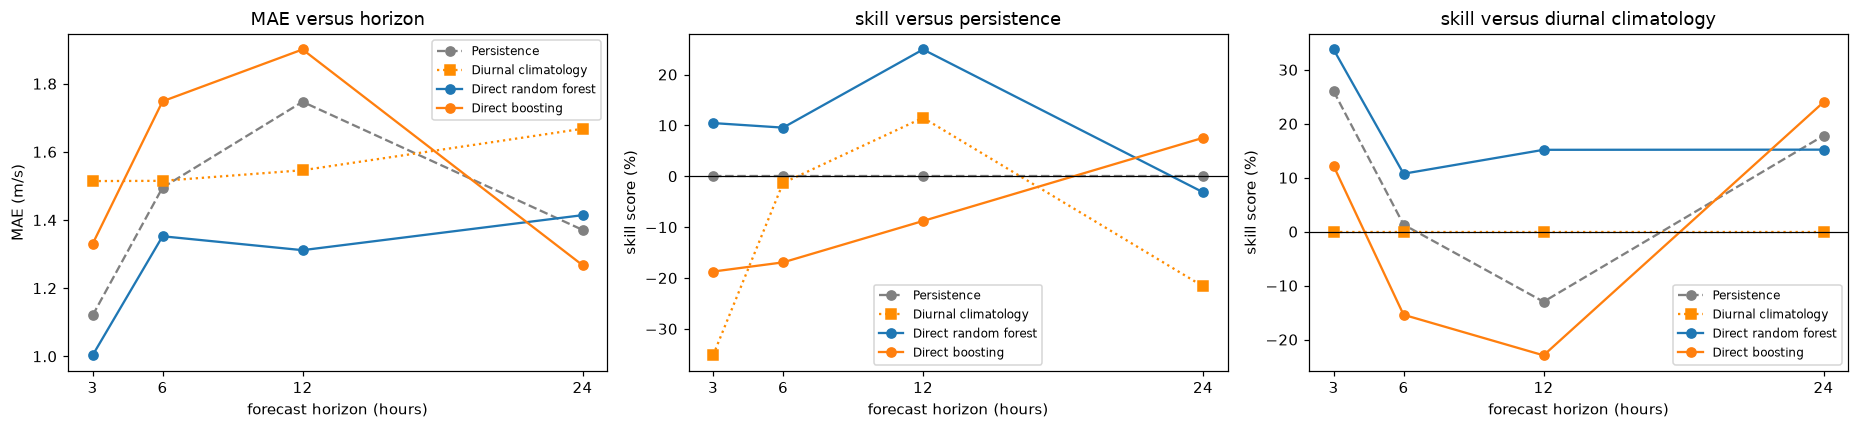

How to read the three panels:
  1. error grows with lead time for everything - the atmosphere forgets;
  2. the persistence skill curve starts high and collapses toward zero (and can
     go negative), which is the quantitative statement of "persistence decays";
  3. the diurnal-climatology curve is the demanding benchmark: a model that beats
     persistence at 24 h but not the diurnal climatology has learned very little
     beyond the time of day.


In [4]:
# Skill versus horizon: the figure that belongs in every wind-forecasting report.
rows = []
for H in HORIZONS:
    pers = DIRECT[H]['Persistence']['metrics']['MAE']
    diur = DIRECT[H]['Diurnal climatology']['metrics']['MAE']
    for name, r in DIRECT[H].items():
        rows.append({'horizon_h': H, 'model': name, 'MAE': r['metrics']['MAE'], 'RMSE': r['metrics']['RMSE'],
                     'R2': r['metrics']['R2'], 'fit_s': r['fit_seconds'],
                     'skill_vs_persistence': 1 - r['metrics']['MAE'] / pers,
                     'skill_vs_diurnal': 1 - r['metrics']['MAE'] / diur})
SCORE = pd.DataFrame(rows)
print(SCORE.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for name in SCORE['model'].unique():
    sel = SCORE[SCORE['model'] == name]
    style = dict(marker='o', ls='--', color='grey') if 'Persistence' in name else (
        dict(marker='s', ls=':', color='darkorange') if 'Diurnal' in name else dict(marker='o'))
    axes[0].plot(sel['horizon_h'], sel['MAE'], label=name, **style)
    axes[1].plot(sel['horizon_h'], 100 * sel['skill_vs_persistence'], label=name, **style)
    axes[2].plot(sel['horizon_h'], 100 * sel['skill_vs_diurnal'], label=name, **style)

axes[0].set_title('MAE versus horizon')
axes[0].set_ylabel('MAE (m/s)')
axes[1].set_title('skill versus persistence')
axes[1].set_ylabel('skill score (%)')
axes[1].axhline(0, color='black', lw=0.8)
axes[2].set_title('skill versus diurnal climatology')
axes[2].set_ylabel('skill score (%)')
axes[2].axhline(0, color='black', lw=0.8)
for ax in axes:
    ax.set_xlabel('forecast horizon (hours)')
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('How to read the three panels:')
print('  1. error grows with lead time for everything - the atmosphere forgets;')
print('  2. the persistence skill curve starts high and collapses toward zero (and can')
print('     go negative), which is the quantitative statement of "persistence decays";')
print('  3. the diurnal-climatology curve is the demanding benchmark: a model that beats')
print('     persistence at 24 h but not the diurnal climatology has learned very little')
print('     beyond the time of day.')

---

## 4. Walk-forward validation

A single validation block gives one number. Walk-forward validation re-fits the model as time advances and scores the *next* unseen block, which is how an operational forecast is actually verified:

```
train ----------------> | block 1 |
train ----------------------> | block 2 |
train ---------------------------> | block 3 |
train --------------------------------> | block 4 |
```

Details that matter:

- **Never train on the future.** Each fold only sees data strictly before its evaluation block.
- **Purge the boundary.** The training part stops `H` hours before the evaluation block starts, for the same reason as in Session 2.
- **Report the dispersion**, not just the mean. Weather years differ; a mean without a spread invites over-claiming.
- **Expanding window versus rolling window.** Expanding means 'use all history'; rolling means 'use only the last N years'. Expanding is the default here; for a changing climate the rolling variant is a defensible alternative (exercise 9).

The loop below walks over the validation block, so the untouched test block of Session 7 remains clean.

In [5]:
def walk_forward(factory, X, y, horizon, n_folds=4, first_val_frac=0.70, name='model', verbose=True):
    """Expanding-window walk-forward over the validation region of the record.

    For each fold:
      train on everything strictly before the block, minus `horizon` rows (purge)
      predict the block, score it, then move forward.

    Returns a DataFrame with one row per fold.
    """
    n = len(y)
    start = int(first_val_frac * n)
    blocks = np.array_split(np.arange(start, n), n_folds)
    rows = []
    for k, block in enumerate(blocks, start=1):
        train_end = block[0] - horizon                      # purge gap
        tr = np.arange(0, max(train_end, 1))
        model = factory()
        t0 = time.time()
        model.fit(X.iloc[tr], y.iloc[tr])
        fit_seconds = time.time() - t0
        pred = model.predict(X.iloc[block])
        m = metrics(y.iloc[block], pred)
        pers = X.iloc[block]['wind_speed_ms'].values
        m_pers = metrics(y.iloc[block], pers)
        rows.append({'fold': k, 'train_rows': len(tr), 'test_rows': len(block),
                     'train_from': X.index[tr[0]].date(), 'train_to': X.index[tr[-1]].date(),
                     'predict_from': X.index[block[0]].date(), 'predict_to': X.index[block[-1]].date(),
                     'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'],
                     'persistence_MAE': m_pers['MAE'],
                     'skill_vs_persistence': 1 - m['MAE'] / m_pers['MAE'],
                     'fit_s': fit_seconds})
        del model
    out = pd.DataFrame(rows)
    if verbose:
        print('walk-forward, H = {} h, {} folds, model = {}'.format(horizon, n_folds, name))
        print(out.round(4).to_string(index=False))
        print('  mean MAE = {:.4f} m/s | std across folds = {:.4f} m/s | mean skill = {:+.1%}'.format(
            out['MAE'].mean(), out['MAE'].std(), out['skill_vs_persistence'].mean()))
        print()
    return out


WALK = {}
for H in HORIZONS:
    D = DATA[H]
    WALK[H] = {}
    WALK[H]['Direct random forest'] = walk_forward(rf_factory, D['X_full'], D['y_full'], H, n_folds=4, name='direct random forest')
    WALK[H]['Direct boosting'] = walk_forward(lambda: booster_factory(), D['X_full'], D['y_full'], H, n_folds=4, name='direct boosting')
    print()

walk-forward, H = 3 h, 4 folds, model = direct random forest
 fold  train_rows  test_rows train_from   train_to predict_from predict_to    MAE   RMSE     R2  persistence_MAE  skill_vs_persistence  fit_s
    1        6027        647 2024-01-02 2024-10-20   2024-10-21 2024-11-26 1.0138 1.3518 0.4005           1.1674                0.1315 2.1007
    2        6674        646 2024-01-02 2024-11-26   2024-11-26 2024-12-28 0.8674 1.3100 0.1823           1.0745                0.1928 2.3322
    3        7320        646 2024-01-02 2024-12-28   2024-12-28 2025-02-03 1.1946 1.8822 0.4322           1.2067                0.0100 2.5505
    4        7966        646 2024-01-02 2025-02-03   2025-02-03 2025-03-08 1.0982 1.6447 0.4729           1.2956                0.1524 2.8677
  mean MAE = 1.0435 m/s | std across folds = 0.1387 m/s | mean skill = +12.2%

walk-forward, H = 3 h, 4 folds, model = direct boosting
 fold  train_rows  test_rows train_from   train_to predict_from predict_to    MAE   RMSE     R

### Interpreting the fold table

Look at three things in your own output:

1. **The mean and the standard deviation of the MAE.** If the standard deviation is comparable to the difference between two models, the ranking between those models is not established. Say so.
2. **The dates.** Which months does each fold cover? A fold that is entirely a calm period will look easy; one dominated by a stormy period will look hard. This is the seasonal-drift effect again, now visible as fold dispersion.
3. **The skill column.** Walk-forward skill versus persistence sometimes goes negative for individual folds even when the model is useful on average. That is expected: on a calm, slowly changing block, persistence is nearly unbeatable.

walk-forward summary (mean over folds):
 horizon_h                model  mean_MAE  std_MAE  mean_persistence_MAE  mean_skill  mean_fit_s  worst_fold_MAE
         3 Direct random forest    1.0435   0.1387                1.1861      0.1217      2.4628          1.1946
         3      Direct boosting    1.0776   0.1958                1.1861      0.0922      1.0854          1.2940
         6 Direct random forest    1.2413   0.1743                1.6075      0.2289      2.6679          1.3923
         6      Direct boosting    1.3172   0.3140                1.6075      0.1821      1.0023          1.7049
        12 Direct random forest    1.3164   0.2157                1.9101      0.3140      2.6060          1.5479
        12      Direct boosting    1.5019   0.3459                1.9101      0.2160      1.0608          1.9144
        24 Direct random forest    1.5247   0.2578                1.6457      0.0608      2.7013          1.8201
        24      Direct boosting    1.5212   0.3739      

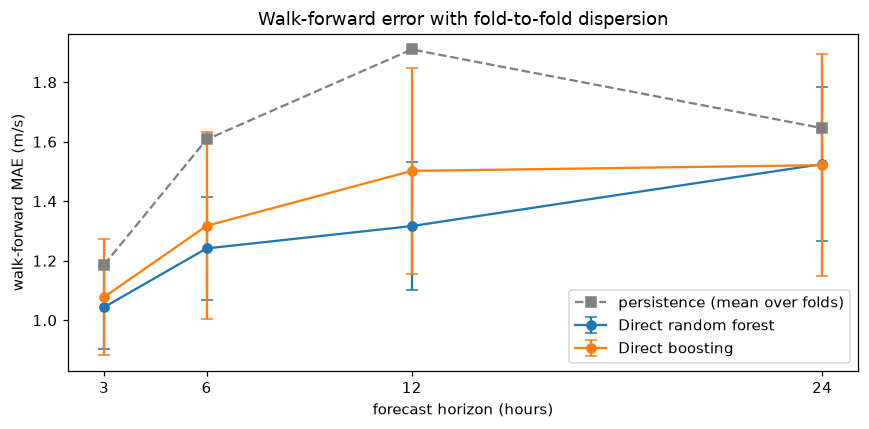

The error bars are the honest part of this figure. A model whose MAE advantage
is smaller than its own fold-to-fold dispersion is not demonstrably better.


In [6]:
summary = []
for H in HORIZONS:
    for name, df in WALK[H].items():
        summary.append({'horizon_h': H, 'model': name, 'mean_MAE': df['MAE'].mean(), 'std_MAE': df['MAE'].std(),
                        'mean_persistence_MAE': df['persistence_MAE'].mean(),
                        'mean_skill': df['skill_vs_persistence'].mean(), 'mean_fit_s': df['fit_s'].mean(),
                        'worst_fold_MAE': df['MAE'].max()})
WALK_SUMMARY = pd.DataFrame(summary)
print('walk-forward summary (mean over folds):')
print(WALK_SUMMARY.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
for name in WALK_SUMMARY['model'].unique():
    sel = WALK_SUMMARY[WALK_SUMMARY['model'] == name]
    ax.errorbar(sel['horizon_h'], sel['mean_MAE'], yerr=sel['std_MAE'], marker='o', capsize=4, label=name)
sel = WALK_SUMMARY[WALK_SUMMARY['model'] == WALK_SUMMARY['model'].iloc[0]]
ax.plot(sel['horizon_h'], sel['mean_persistence_MAE'], marker='s', ls='--', color='grey', label='persistence (mean over folds)')
ax.set_xlabel('forecast horizon (hours)')
ax.set_ylabel('walk-forward MAE (m/s)')
ax.set_xticks(HORIZONS)
ax.set_title('Walk-forward error with fold-to-fold dispersion')
ax.legend()
plt.tight_layout()
plt.show()

print('The error bars are the honest part of this figure. A model whose MAE advantage')
print('is smaller than its own fold-to-fold dispersion is not demonstrably better.')

---

## 5. Multi-step forecasting: direct versus recursive

The controlled experiment below uses a deliberately **reduced** feature set built only from wind speed and the time of day. That keeps the recursion well defined: at every step we know exactly which values we must synthesise.

1. Train a **single-step** model (`T+1`) on the training block.
2. From each origin in the validation block, roll it forward 24 hours, feeding predictions back in as the 'observed' history.
3. Compare the resulting 1-24 h error curve with the **direct** models trained for fixed horizons.

Two things should come out of this experiment. First, **recursion error grows quickly with lead time**, because every step carries the previous step's error - that growth is the quantity you must report if you deploy a roll-out. Second, a fair comparison between the two strategies requires **identical features**: our direct models use 72 multivariate predictors, whereas the recursion is driven by a deliberately minimal wind-speed-only model, because a 72-feature recursion would have to invent pressure, humidity and temperature at every step. The comparison below is therefore a study of error accumulation, not a contest - and the caveat is part of the lesson.

In [7]:
def build_ws_only_frame(hourly):
    """Minimal feature frame for the recursion experiment: wind speed + clock only."""
    ws = hourly['wind_speed_ms']
    df = pd.DataFrame(index=hourly.index)
    df['ws'] = ws
    df['ws_lag1'] = ws.shift(1)
    df['ws_lag2'] = ws.shift(2)
    df['ws_lag3'] = ws.shift(3)
    df['ws_roll3'] = ws.shift(1).rolling(3).mean()          # = mean(lag1, lag2, lag3)
    df['hour_sin'] = np.sin(2 * np.pi * hourly.index.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * hourly.index.hour / 24.0)
    return df


WS_ONLY = build_ws_only_frame(hourly)
WS_FEATURES = list(WS_ONLY.columns)

# single-step target: the value one hour later (this is the recursive strategy's model)
y1 = hourly['wind_speed_ms'].shift(-1)
valid = WS_ONLY.notna().all(axis=1) & y1.notna()
X1, y1 = WS_ONLY[valid], y1[valid]
tr1, va1, te1 = chronological_split(len(y1), gap=1)

one_step_model = booster_factory(n_estimators=300, learning_rate=0.05)
one_step_model.fit(X1.iloc[tr1], y1.iloc[tr1])
print('single-step model trained on {} rows, {} features'.format(len(tr1), len(WS_FEATURES)))
print('  single-step validation MAE = {:.4f} m/s'.format(
    metrics(y1.iloc[va1], one_step_model.predict(X1.iloc[va1]))['MAE']))

# --- recursive roll-out from many origins at once (batched, one pass per lead time)
def recursive_rollout(model, hourly, origins, horizon=24):
    """Roll a single-step model forward from each origin; return an array (n_origins, horizon)."""
    ws = hourly['wind_speed_ms']
    positions = [ws.index.get_loc(t) for t in origins]
    cur = np.array([ws.iloc[p] for p in positions], dtype=float)
    lag1 = np.array([ws.iloc[p - 1] for p in positions], dtype=float)
    lag2 = np.array([ws.iloc[p - 2] for p in positions], dtype=float)
    lag3 = np.array([ws.iloc[p - 3] for p in positions], dtype=float)
    hours = pd.DatetimeIndex(origins)
    out = np.zeros((len(origins), horizon))
    for h in range(1, horizon + 1):
        stamp = hours + pd.Timedelta(hours=h)
        batch = pd.DataFrame({'ws': cur, 'ws_lag1': lag1, 'ws_lag2': lag2, 'ws_lag3': lag3,
                              'ws_roll3': (lag1 + lag2 + lag3) / 3.0,
                              'hour_sin': np.sin(2 * np.pi * stamp.hour / 24.0),
                              'hour_cos': np.cos(2 * np.pi * stamp.hour / 24.0)})[WS_FEATURES]
        pred = model.predict(batch)
        out[:, h - 1] = pred
        lag3, lag2, lag1 = lag2, lag1, cur
        cur = pred
    return out


# origins: every 4th hour of the validation block, so the roll-out stays fast
val_times = y1.index[va1]
origins = val_times[::4]
recursive_path = recursive_rollout(one_step_model, hourly, origins, horizon=24)

# verify the roll-out against the observed series for lead time 1
lead1_true = np.array([hourly['wind_speed_ms'].loc[t + pd.Timedelta(hours=1)] for t in origins])
print()
print('sanity check of the roll-out at lead time 1: MAE = {:.4f} m/s'.format(
    np.nanmean(np.abs(recursive_path[:, 0] - lead1_true))))
print('(this one-step number should be close to the single-step validation MAE above)')

single-step model trained on 7198 rows, 7 features
  single-step validation MAE = 0.6809 m/s


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3294700489.py:42: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  stamp = hours + pd.Timedelta(hours=h)
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3294700489.py:42: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  stamp = hours + pd.Timedelta(hours=h)
C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\3294700489.py:42: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  stamp = hours + pd.Timedelta(hours=h)
C:\Users\Amir\AppData\Local\Temp\ipykern


sanity check of the roll-out at lead time 1: MAE = 0.6777 m/s
(this one-step number should be close to the single-step validation MAE above)


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\137334428.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  truth = np.array([hourly['wind_speed_ms'].loc[t + pd.Timedelta(hours=h)] for t in origins])


 lead_h  recursive_MAE  recursive_RMSE
      1         0.6777          0.9730
      2         0.9957          1.5021
      3         1.1783          1.7981
      4         1.2145          1.8211
      5         1.2485          1.9213
      6         1.3334          2.0393
      7         1.4218          2.1536
      8         1.3963          2.1590
      9         1.4550          2.2694
     10         1.5064          2.3490
     11         1.5598          2.4365
     12         1.4901          2.4065
     13         1.5138          2.4230
     14         1.5486          2.4357
     15         1.5868          2.4813
     16         1.5177          2.4318
     17         1.4994          2.4100
     18         1.5455          2.4458
     19         1.5994          2.4989
     20         1.5270          2.4685
     21         1.5212          2.4526
     22         1.5474          2.4957
     23         1.5972          2.5269
     24         1.5294          2.5147


C:\Users\Amir\AppData\Local\Temp\ipykernel_10648\137334428.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  pers = [np.mean(np.abs(np.array([hourly['wind_speed_ms'].loc[t + pd.Timedelta(hours=h)] for t in origins])


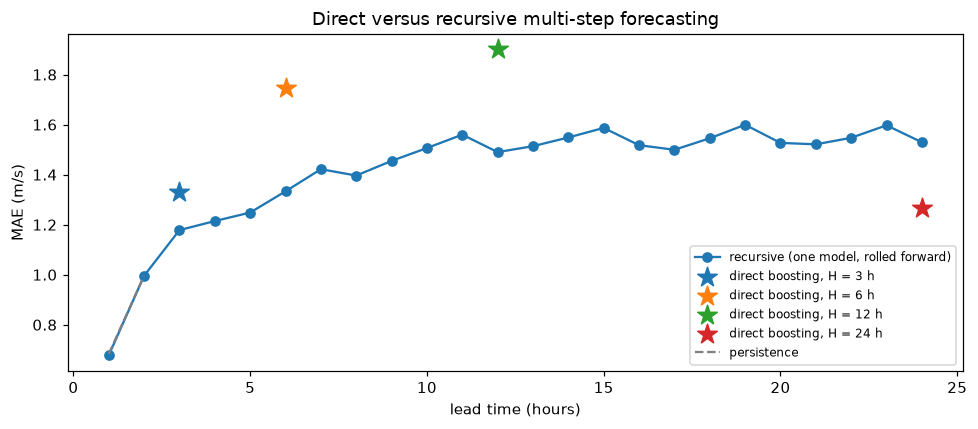

Reading the curve:
  - recursive error grows from roughly 0.7 m/s at lead 1 to roughly 1.5 m/s at
    lead 24. That growth IS the accumulation of its own mistakes, and it is the
    number you must quote whenever you deploy a roll-out;
  - the stars are direct models trained on the FULL 72-feature set, while the
    curve comes from a deliberately minimal wind-speed-only model. The comparison
    is therefore NOT a like-for-like test of the two strategies: at some lead
    times the minimal recursive model even beats the direct one.
  - that is the actual lesson here: comparing direct with recursive forecasting
    requires identical features. With a multivariate feature set, recursion also
    forces you to synthesise pressure, humidity, temperature and their lags at
    every step, which is why operational systems use the direct approach - or
    recursion driven by external NWP inputs rather than by the model itself.


In [8]:
# Error growth with lead time: recursive roll-out versus direct models.
rows = []
for h in range(1, 25):
    truth = np.array([hourly['wind_speed_ms'].loc[t + pd.Timedelta(hours=h)] for t in origins])
    pred = recursive_path[:, h - 1]
    ok = ~np.isnan(truth)
    rows.append({'lead_h': h, 'recursive_MAE': np.mean(np.abs(truth[ok] - pred[ok])),
                 'recursive_RMSE': np.sqrt(np.mean((truth[ok] - pred[ok]) ** 2))})
GROWTH = pd.DataFrame(rows)
print(GROWTH.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(GROWTH['lead_h'], GROWTH['recursive_MAE'], marker='o', label='recursive (one model, rolled forward)')
for H in HORIZONS:
    ax.scatter([H], [DIRECT[H]['Direct boosting']['metrics']['MAE']], marker='*', s=180, zorder=5,
               label='direct boosting, H = {} h'.format(H))
pers = [np.mean(np.abs(np.array([hourly['wind_speed_ms'].loc[t + pd.Timedelta(hours=h)] for t in origins])
                       - np.array([hourly['wind_speed_ms'].loc[t] for t in origins]))) for h in range(1, 25)]
ax.plot(range(1, 25), pers, ls='--', color='grey', label='persistence')
ax.set_xlabel('lead time (hours)')
ax.set_ylabel('MAE (m/s)')
ax.set_title('Direct versus recursive multi-step forecasting')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Reading the curve:')
print('  - recursive error grows from roughly 0.7 m/s at lead 1 to roughly 1.5 m/s at')
print('    lead 24. That growth IS the accumulation of its own mistakes, and it is the')
print('    number you must quote whenever you deploy a roll-out;')
print('  - the stars are direct models trained on the FULL 72-feature set, while the')
print('    curve comes from a deliberately minimal wind-speed-only model. The comparison')
print('    is therefore NOT a like-for-like test of the two strategies: at some lead')
print('    times the minimal recursive model even beats the direct one.')
print('  - that is the actual lesson here: comparing direct with recursive forecasting')
print('    requires identical features. With a multivariate feature set, recursion also')
print('    forces you to synthesise pressure, humidity, temperature and their lags at')
print('    every step, which is why operational systems use the direct approach - or')
print('    recursion driven by external NWP inputs rather than by the model itself.')

### Which strategy would you deploy?

| Consideration | Direct | Recursive |
|---|---|---|
| Accuracy at fixed horizons | better | worse |
| Cost | one model per horizon (4 here) | one model |
| Maintenance | retrain all horizons | retrain one |
| Long sequences (e.g. 10-day outlook) | needs a model per step | natural |
| Error accounting | per-horizon metrics are honest | errors are correlated across lead times |

For an operational wind forecast at 3/6/12/24 h, **direct** is the right choice and the one we carry forward. Recursion is the tool for producing a continuous curve without training dozens of models, and its error growth must then be reported as part of the forecast uncertainty.

**Check for understanding:** a colleague trains one 1-hour model and rolls it out 24 hours, reporting the MAE at 1 hour as the model's performance. What is wrong? *The reported number describes lead time 1, not the product they are delivering (24-hour forecasts). The verified number must be measured at each lead time actually used.*

---

## 6. Common pitfalls and mistakes in machine-learning weather forecasting

**Mistake 1 - shuffling rows.**  
Inflates every score. Demonstrated in Session 2.

**Mistake 2 - building windows over the target.**  
A rolling mean that includes `T` when `T` is also the target, or a window centred on the valid time, embeds the answer.

**Mistake 3 - reporting one number for all horizons and all conditions.**  
A single MAE hides that the 3-hour forecast is excellent and the 24-hour forecast barely beats climatology, and that both fail in storms. Always report the horizon breakdown (this session) and the regime breakdown (Session 6).

**Mistake 4 - verifying on the training season.**  
Our validation block is autumn/winter while training is spring/summer. Reporting only the training-season score would flatter the model. Walk-forward folds expose this.

**Mistake 5 - confusing forecast origin with valid time.**  
Joining a forecast to the observation at the origin instead of at `T+H` produces a beautiful, meaningless correlation.

**Mistake 6 - ignoring error correlation.**  
Two consecutive hourly forecasts are not independent samples: the effective sample size is much smaller than the row count. Confidence intervals computed as if rows were independent are far too narrow.

**Mistake 7 - treating a negative skill as a bug.**  
On a calm, persistent block, *no* model beats persistence. Report it; do not tune it away.

**Mistake 8 - forgetting the physical limit.**  
Trees cannot produce values outside the training range, so extreme events are systematically under-forecast. Say so in the limitations section rather than quietly clipping.

**Mistake 9 - measuring the model, not the product.**  
If the operational product is a 24-hour forecast issued at 06:00, then verify at 24 hours from 06:00 origins only. The average over all origins can differ materially.

---

## 7. AI-assisted workflow

### 7.1 Prompts that help here

| Goal | Prompt |
|---|---|
| get the vocabulary right | 'Define forecast origin, lead time, valid time, direct and recursive multi-step forecasting, with one concrete example each for an hourly station record.' |
| implement walk-forward | 'Write a walk-forward validation loop for hourly data with H-hour-ahead direct forecasting. Each fold must train only on strictly earlier data, with a purge of H rows, and return per-fold MAE, RMSE and dates. Explain the purge.' |
| implement a roll-out | 'Write a vectorised recursive multi-step forecaster: given a single-step model, the observed history of wind speed and a list of origins, produce forecasts for lead times 1 to 24. Point out every place where the inputs must be replaced by predictions.' |
| interrogate a curve | 'My recursive forecast error grows from 0.8 to 2.1 m/s over 24 hours while my direct model at 24 h gives 1.5. Explain the mechanism and how to present both curves honestly.' |

### 7.2 Debugging prompts

```
My recursive roll-out starts from the true observed wind speed at the origin, and my
lead-1 MAE matches my single-step validation MAE, but by lead 3 the predictions look
frozen near the training mean.
Here is the roll-out code: <paste>.
What are the three most likely causes, and which single check isolates each one?
```

Typical causes: the lags are not being updated between steps, the model is a tree that cannot extrapolate and saturates, or the batch columns are ordered differently from the training columns (a silent misalignment that produces plausible-looking numbers).

### 7.3 Code-review prompt

```
Review this multi-horizon evaluation code as a strict reviewer.
Check specifically: (1) is the target at T+H for every horizon, with no off-by-one?
(2) does any fold train on data later than its evaluation block? (3) is the purge
gap present and equal to H? (4) are persistence and the diurnal climatology computed
from the same origins and the same rows? (5) is any number reported without its
dispersion? Quote the lines and rate the severity.
```

### 7.4 Validation checklist

1. **Alignment test.** For one origin, print the target and the raw observed value at `T+H`; they must be equal.
2. **Lead-1 sanity check.** The recursive roll-out's first step should reproduce the single-step model's validation MAE almost exactly. If it does not, the batching is wrong.
3. **Baseline parity.** Baselines must be evaluated on exactly the same origins as the models.
4. **Fold dates printed.** Know which months each fold covers before interpreting the spread.
5. **No test-block access.** In this session, `y_test` is created but never scored.
6. **Same-row check.** `len(true) == len(pred)` for every published number.

### 7.5 Exercise

Ask an LLM to 'produce a validation set for hourly wind-speed forecasting'. Then check whether it (a) splits by time, (b) purges an `H`-hour gap, (c) keeps the baseline on the same rows. Most answers fail at least one; annotating *why* each failure matters is exactly the skill this course is building.

---

## 8. Exercises

### Level 1 - understanding

1. Define forecast origin, lead time and valid time for the statement 'the model issued at 06:00 forecasts 1.9 m/s for 18:00'.
2. Why does a 24-hour forecast benefit more from calendar features than a 3-hour forecast?
3. What exactly accumulates in a recursive roll-out, and what does not accumulate in the direct strategy?
4. Why must baselines be re-scored at every horizon?

### Level 2 - implementation

5. Extend the skill-versus-horizon figure with a model trained on a *subset* of features (wind speed only) and describe what is lost.
6. Run walk-forward validation with 8 folds instead of 4. Does the mean MAE change? Does the dispersion change? Which is more informative?
7. Implement a rolling-window walk-forward variant (train only on the previous 12 months) and compare it with the expanding version.
8. Add a 'day-of-year climatology' baseline (training-period mean per month) to every horizon and check where it wins.
9. Produce a direct model for every lead time 1-48 h and plot the resulting error curve against the recursive roll-out.

### Level 3 - reasoning

10. Two models have mean walk-forward MAE 1.30 and 1.32 m/s, with fold standard deviations of 0.20 m/s. Write the two-sentence conclusion.
11. Explain why the effective sample size of hourly forecast errors is smaller than the number of rows, and what that implies for confidence intervals.
12. Your recursive roll-out flattens toward the mean after a few steps. Is that a bug, a property of trees, or a physical statement? Justify your answer.
13. The diurnal climatology beats your model at 24 h on one fold but not on average. Describe how to investigate this without touching the test block.

### Level 4 - application (project work)

14. **Produce the multi-horizon evaluation section of your report.** Include: the skill-versus-horizon figure, the walk-forward table with dispersion, the direct-versus-recursive comparison, and three sentences of interpretation referring to specific numbers.
15. **Write the forecast-product specification.** For an operational user (say an air-quality office), define the origins, the horizons, the metric that matters, the acceptable error, and which model you would deploy at each horizon. This is the paragraph that turns your notebook into a usable product.

---

## 9. Reproducibility notes

- **One source:** `data/raw/abali.xlsx`, cleaned in memory, nothing written to disk.
- **Seeds:** `SEED = 42` for every model. LightGBM/XGBoost subsampling also uses it.
- **Walk-forward definition is data.** The fold boundaries are printed with their dates and row counts; quote them in the report, because a different fold split gives different numbers.
- **Origins in the roll-out are strided by 4 hours** to keep the classroom run fast. Change the stride and the numbers move slightly; report the stride you used.
- **Toggles:** `QUICK_MODE`, `N_TREES`, `N_JOBS`, `n_folds`, the roll-out stride.
- **The test block remains untouched.** It is created in this notebook only to be used in Session 7.

---

## 10. Key takeaways

1. Error grows with lead time because the atmosphere forgets; the useful predictors and the dominant baseline both change with the horizon.
2. Direct multi-horizon forecasting trains one model per horizon and avoids error accumulation; recursive forecasting trains one model and feeds predictions back.
3. Our roll-out isolates error accumulation quantitatively (about 0.7 m/s at lead 1 to about 1.5 m/s at lead 24) and shows why direct models are the operational choice for fixed horizons: recursion with a multivariate feature set would have to synthesise every input at every step.
4. Walk-forward validation with a purge gap is the operational verification standard; report the fold dispersion, not just the mean.
5. Skill must be reported against both persistence and the diurnal climatology, at every horizon.
6. A negative skill on a calm block is a physical outcome, not a bug.

In [9]:
# ===========================================================================
# FINAL VALIDATION CELL - run last, in every notebook
# ===========================================================================
WARNINGS = []
if not HAS_LGBM:
    WARNINGS.append('lightgbm not installed: boosting provided by XGBoost or sklearn GradientBoostingRegressor')
if not HAS_XGB:
    WARNINGS.append('xgboost not installed')
if QUICK_MODE:
    WARNINGS.append('QUICK_MODE=True: {} trees, {} walk-forward folds'.format(N_TREES, 4))
WARNINGS.append('recursive roll-out uses every 4th origin of the validation block (runtime), so its curve is slightly noisier than a full roll-out')
WARNINGS.append('validation block is autumn/winter: absolute errors are pessimistic relative to a same-season evaluation')

manifest = {
    'notebook': '05_time_series_forecasting_multi_horizon_abali.ipynb',
    'session': 'Session 5 - time-series forecasting and multi-horizon evaluation',
    'dataset_used': RAW_PATH + ' (Abali station, hourly, cleaned in memory)',
    'target_variable': 'wind_speed_ms at T + H (m/s), direct multi-horizon',
    'forecast_horizons_hours': HORIZONS,
    'strategies_compared': ['direct multi-horizon (one model per H)', 'recursive multi-step (one single-step model rolled forward to 24 h)'],
    'models_used': ['Persistence', 'Diurnal climatology', 'Direct random forest', 'Direct boosting', 'Recursive boosting (single-step model)'],
    'validation_schemes': ['single chronological validation block', 'expanding-window walk-forward with 4 folds and a purge gap of H hours'],
    'metrics_used': ['MAE', 'MSE', 'RMSE', 'R2', 'skill_vs_persistence', 'skill_vs_diurnal_climatology'],
    'validation_MAE_by_horizon': {str(H): {k: float(v['metrics']['MAE']) for k, v in DIRECT[H].items()} for H in HORIZONS},
    'walk_forward_mean_MAE': {str(H): {k: float(v['MAE'].mean()) for k, v in WALK[H].items()} for H in HORIZONS},
    'recursive_MAE_lead_1': float(GROWTH.loc[0, 'recursive_MAE']),
    'recursive_MAE_lead_24': float(GROWTH.loc[23, 'recursive_MAE']),
    'test_block_touched': False,
    'files_written': 'none (all work in memory)',
    'random_seed': SEED,
    'warnings': WARNINGS,
}
print(json.dumps(manifest, indent=2, default=str))

{
  "notebook": "05_time_series_forecasting_multi_horizon_abali.ipynb",
  "session": "Session 5 - time-series forecasting and multi-horizon evaluation",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, hourly, cleaned in memory)",
  "target_variable": "wind_speed_ms at T + H (m/s), direct multi-horizon",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "strategies_compared": [
    "direct multi-horizon (one model per H)",
    "recursive multi-step (one single-step model rolled forward to 24 h)"
  ],
  "models_used": [
    "Persistence",
    "Diurnal climatology",
    "Direct random forest",
    "Direct boosting",
    "Recursive boosting (single-step model)"
  ],
  "validation_schemes": [
    "single chronological validation block",
    "expanding-window walk-forward with 4 folds and a purge gap of H hours"
  ],
  "metrics_used": [
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "skill_vs_persistence",
    "skill_vs_diurnal_climatology"
  ],
  "validation_M

---

### What comes next

In **Session 6** we stop asking *how accurate* the model is and start asking *what it learned and where it fails*:

- feature importance and permutation importance, and how to read them without over-interpreting;
- optional SHAP values for per-prediction explanations;
- residual analysis, including the diurnal error cycle;
- error by wind regime - calm, moderate and stormy - which is where the scientific insight lives;
- and the professional half of the session: how to use an LLM for generation, review, debugging and verification without surrendering your judgement.

Before then, complete exercises 10, 12 and 15; exercise 15 is the operational summary of your project.